## 1 · Imports

In [1]:
# import scvelo as scv
from multiprocessing import Pool

import anndata as ad
import matplotlib as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib import rcParams

In [2]:
import mudata as mu

In [3]:
import os
from functools import partial
from pathlib import Path
from typing import Optional

import altair as alt

# Libraries
import anndata as ad
import decoupler as dc
import matplotlib as plt
import mudata as mu
import numpy as np
import pandas as pd
import scanpy as sc
import scirpy as ir
import seaborn as sns
from anndata import AnnData
from matplotlib.pyplot import rc_context
from scipy.sparse import csr_matrix
from scipy.stats import median_abs_deviation

alt.data_transformers.enable("vegafusion")

import anndata as ad
import numpy as np
import palantir
import scipy.sparse as sp

In [4]:
import scanpy as sc

sc.settings.figdir = "/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/publication_figures/healthy"


## 2 · Data Loading

Load mudata

In [5]:
#mdata = mu.read_h5mu("001_create_mudata_normal.h5mu")

In [6]:
mdata = mu.read_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/single_cell_normal/001_create_mudata_normal.h5mu")

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/anndata/utils.py:354: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adop

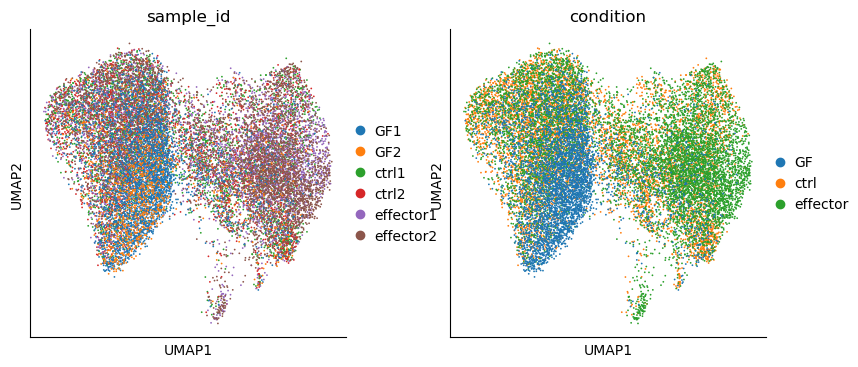

In [7]:
sc.pl.umap(mdata["gex"], color=["sample_id", "condition"])

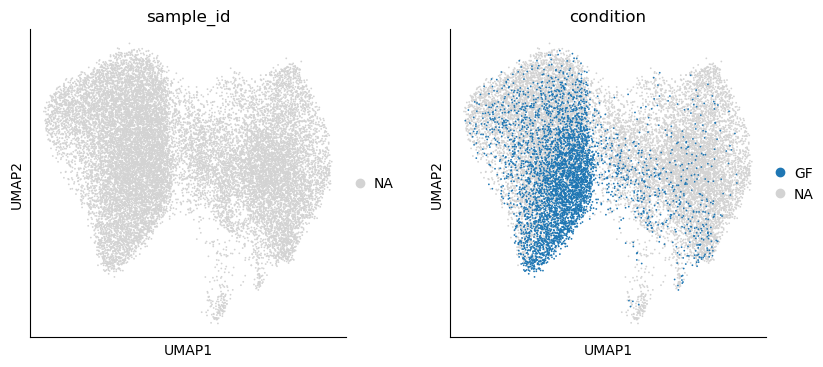

In [8]:
sc.pl.umap(mdata["gex"], color=["sample_id", "condition"], groups=["GF"])

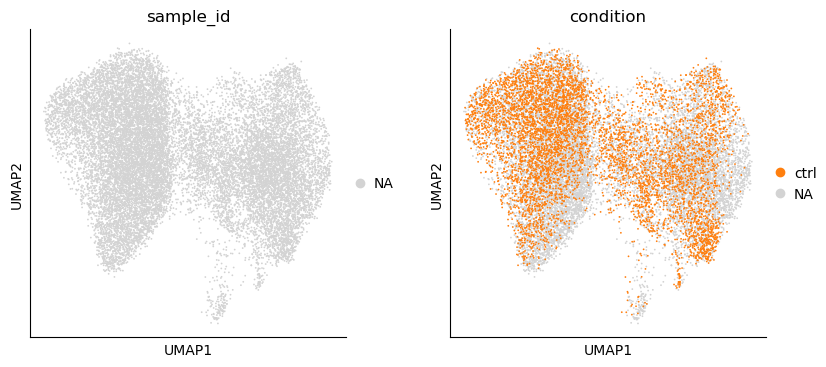

In [9]:
sc.pl.umap(mdata["gex"], color=["sample_id", "condition"], groups=["ctrl"])

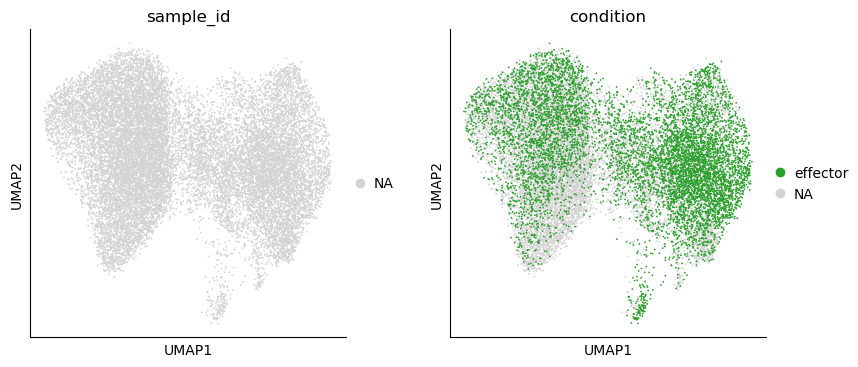

In [10]:
sc.pl.umap(mdata["gex"], color=["sample_id", "condition"], groups=["effector"])

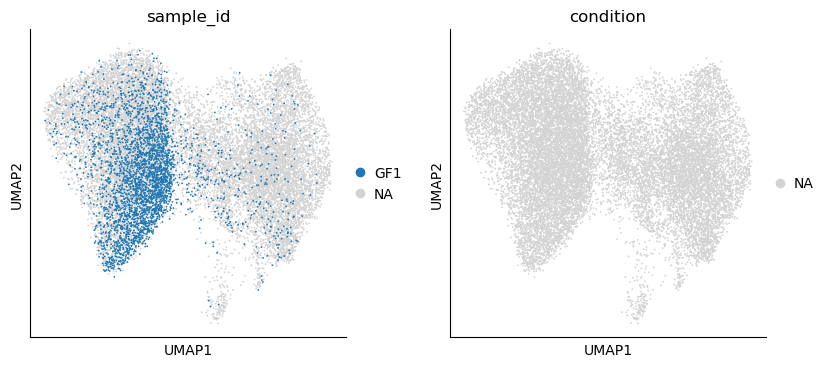

In [11]:
sc.pl.umap(mdata["gex"], color=["sample_id", "condition"], groups=["GF1"])

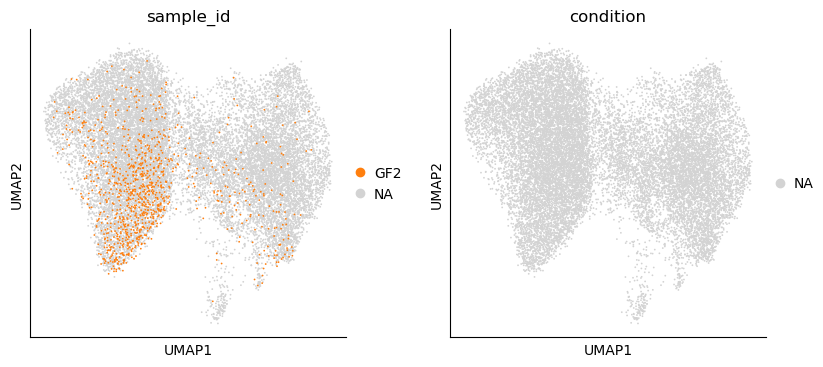

In [12]:
sc.pl.umap(mdata["gex"], color=["sample_id", "condition"], groups=["GF2"])

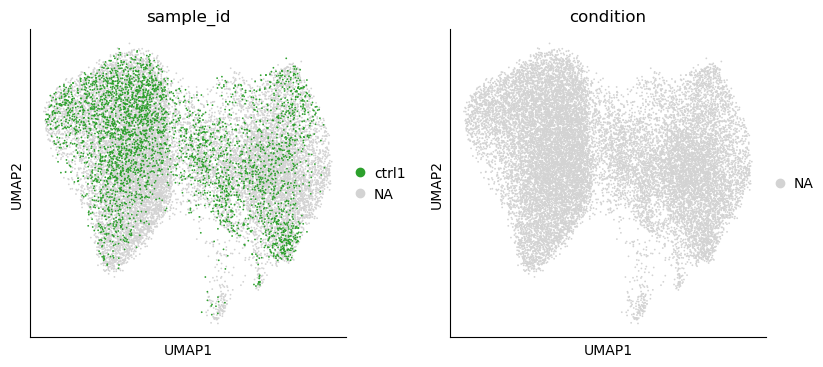

In [13]:
sc.pl.umap(mdata["gex"], color=["sample_id", "condition"], groups=["ctrl1"])

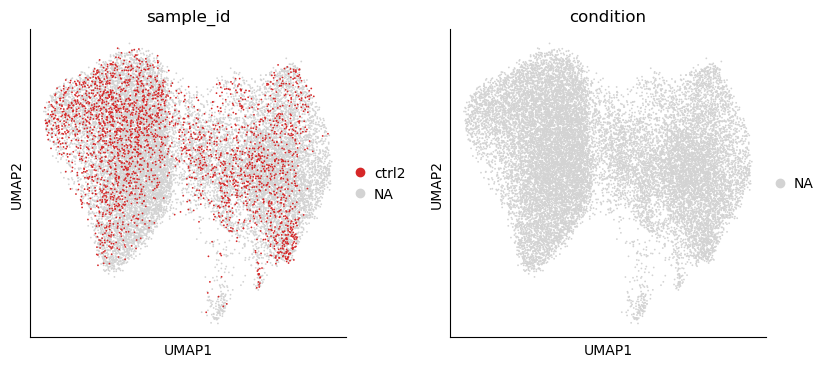

In [14]:
sc.pl.umap(mdata["gex"], color=["sample_id", "condition"], groups=["ctrl2"])

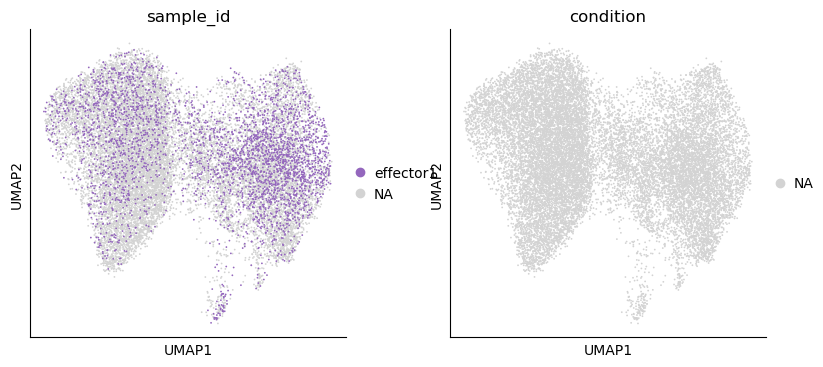

In [15]:
sc.pl.umap(mdata["gex"], color=["sample_id", "condition"], groups=["effector1"])

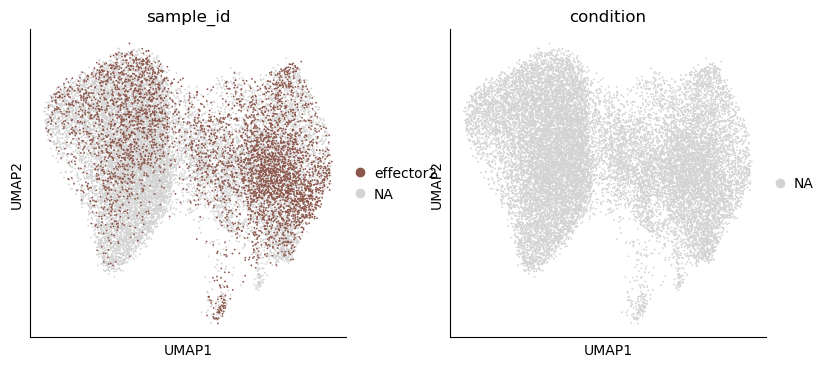

In [16]:
sc.pl.umap(mdata["gex"], color=["sample_id", "condition"], groups=["effector2"])

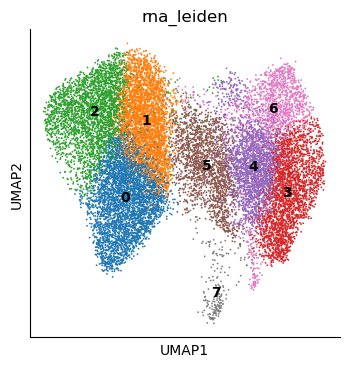

In [17]:
sc.pl.umap(
    mdata["gex"], color=["rna_leiden"], legend_loc="on data"
)  # , groups = ["7"])

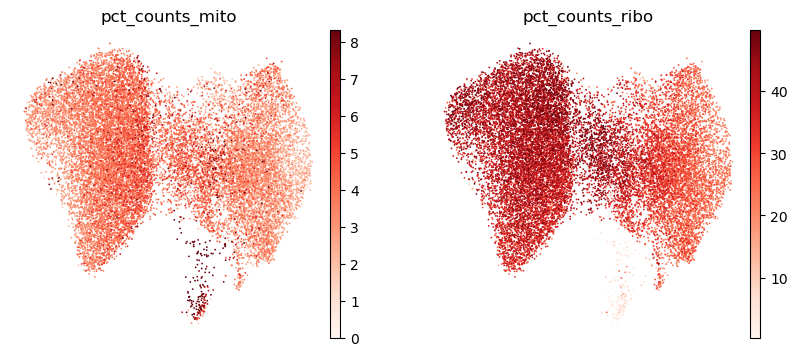

In [18]:
sc.pl.umap(
    mdata["gex"], color=["pct_counts_mito","pct_counts_ribo"], frameon=False, vmax="p99", cmap= "Reds"  # , legend_loc="on data"
)

In [19]:
sc.tl.leiden(mdata["gex"], resolution=1.2, key_added="rna_leiden_12")

/tmp/ipykernel_3201554/1182886572.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(mdata["gex"], resolution=1.2, key_added="rna_leiden_12")


In [20]:
sc.tl.leiden(mdata["gex"], resolution=2, key_added="rna_leiden_2")

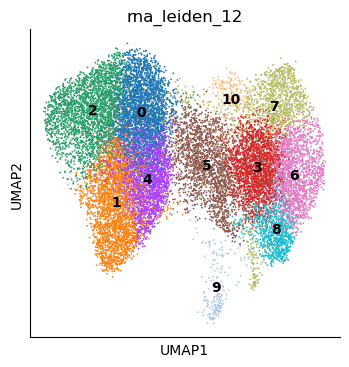

In [21]:
sc.pl.umap(
    mdata["gex"], color=["rna_leiden_12"], legend_loc="on data"
)  # , groups = ["7"])

In [22]:
# 1. Pull out the GEX layer, filter out cluster '7', and copy the independent slice
mdata.mod["gex"] = mdata["gex"][
    mdata["gex"].obs["rna_leiden_12"] != "9"
].copy()

# 2. Update the parent MuData object to synchronize the global indices across modalities
mdata.update()

print(f"Remaining cells in GEX layer: {mdata['gex'].shape[0]}")

Remaining cells in GEX layer: 18263


/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


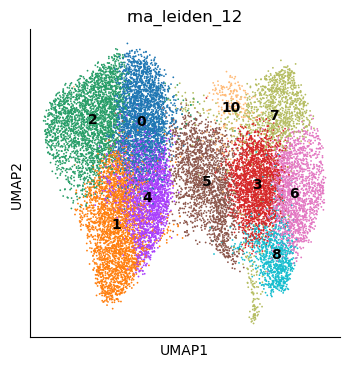

In [23]:
sc.pl.umap(
    mdata["gex"], color=["rna_leiden_12"], legend_loc="on data"
)  # , groups = ["7"])

## 4 · Gene marker ploting


In [24]:
import scanpy as sc


def plot_marker_umaps(adata, marker_dict, title_prefix):
    for category, genes in marker_dict.items():
        genes = sorted(list(genes))
        genes_present = [g for g in genes if g in adata.var_names]

        if len(genes_present) == 0:
            print(f"No genes found for {category}")
            continue

        print(f"Plotting {category}: {genes_present}")

        sc.pl.umap(
            adata,
            color=genes_present,
            ncols=4,
            cmap="Reds",
            vmax="p99",
            title=[f" {category} | {g}" for g in genes_present],
            frameon=False,
        )

In [25]:
gene_markers = {
    "Naive": {
        "Sell",
        "Ccr7",  #  \(CD44^{lo}\), \(CD62L^{hi}\), \(CCR7^{hi}\)
        "Cd44",
    },    "Activated": {"Tbx21","Ccl5","Ctla2a",
       
    },"Effector_memory":{"Cxcr3","Gzmk","Gzmb","Gzma",#,"Pdcd1","Havcr2",
       "Itgae",},

}

Plotting Naive: ['Ccr7', 'Cd44', 'Sell']


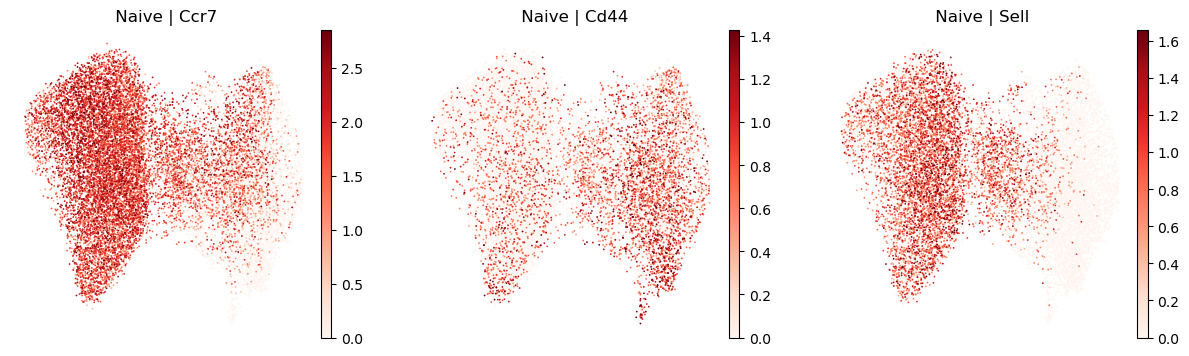

Plotting Activated: ['Ccl5', 'Ctla2a', 'Tbx21']


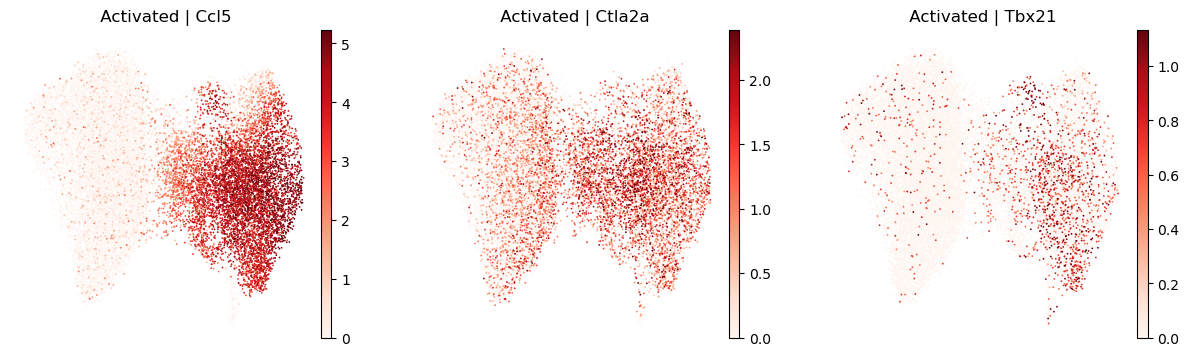

Plotting Effector_memory: ['Cxcr3', 'Gzma', 'Gzmb', 'Gzmk', 'Itgae']


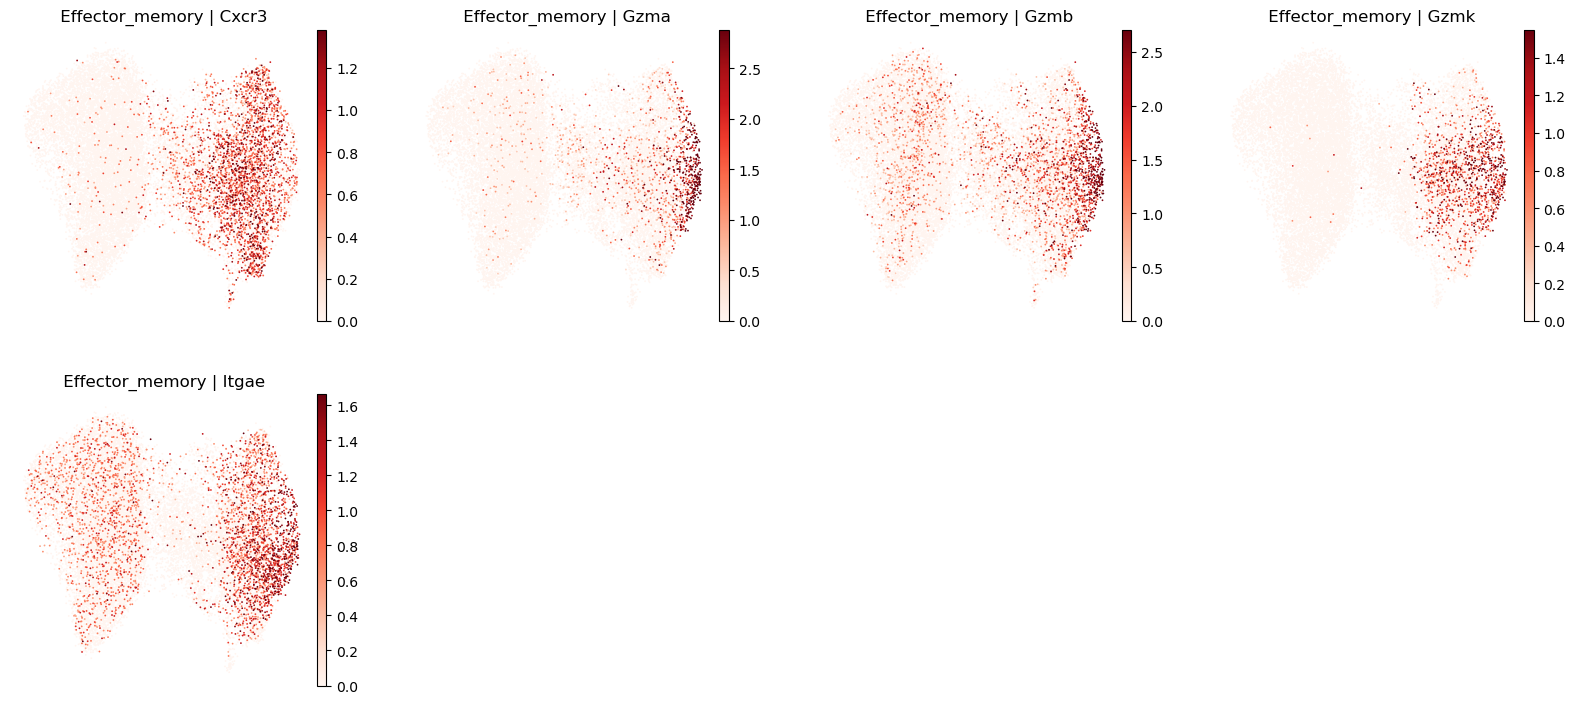

In [26]:
plot_marker_umaps(
    adata=mdata["gex"], marker_dict=gene_markers, title_prefix="Gene markers"
)

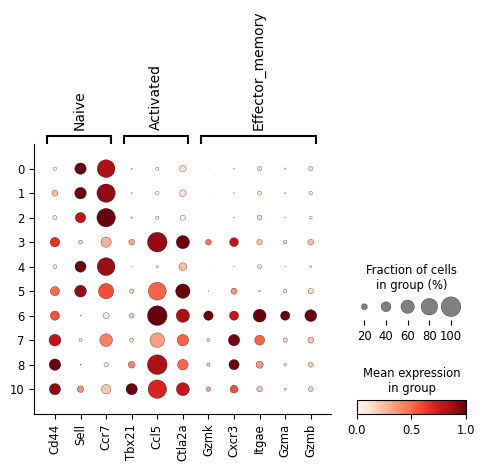

In [27]:
from matplotlib import cm

sc.pl.dotplot(
    mdata["gex"],
    gene_markers,
    groupby="rna_leiden_12",
    standard_scale="var",
    dendrogram=False,
    swap_axes=False,  # ,save="annotation.svg"
)


## naive #  \(CD44^{lo}\), \(CD62L^{hi}\), \(CCR7^{hi}\)

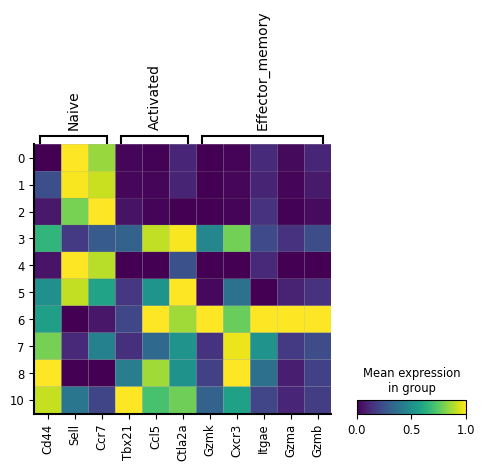

In [28]:
from matplotlib import cm

sc.pl.matrixplot(
    mdata["gex"],
    gene_markers,
    groupby="rna_leiden_12",
    standard_scale="var",
    dendrogram=False,
    swap_axes=False,  # ,save="annotation.svg"
)

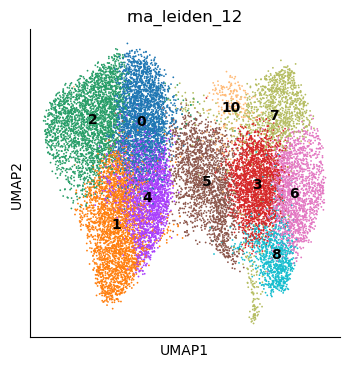

In [29]:
sc.pl.umap(
    mdata["gex"], color=["rna_leiden_12"], legend_loc="on data")
#   , groups = ["7"])

## 5 · Annotation


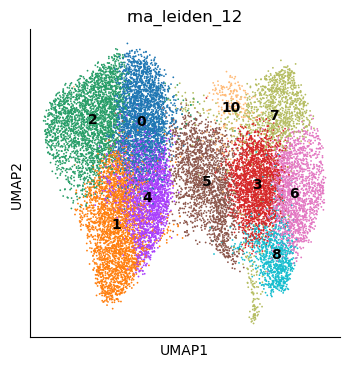

In [30]:
sc.pl.umap(
    mdata["gex"], color=["rna_leiden_12"], legend_loc="on data"
)  # , groups = ["7"])

In [31]:
# Check unique clusters first (optional, but recommended)
print(mdata["gex"].obs["rna_leiden_12"].unique())

# Create mapping dictionary (adjust numbers if needed)
cluster_annotation = {
    "0": "Naive",
    "1": "Naive",
    "2": "Naive",
    "3": "Activated",
    "4": "Naive",
    "5": "Activated",
    "6": "Effector_memory",
    "7":"Effector_memory",
    "8":"Effector_memory",
    "10":"Activated",

}

# If gex03 is integer instead of string, remove the quotes in dictionary keys
# e.g., 0: "Activated"

# Create new annotation column
mdata["gex"].obs["cell_annotation_05"] = (
    mdata["gex"].obs["rna_leiden_12"].map(cluster_annotation)
)

# Make it categorical (recommended for plotting)
mdata["gex"].obs["cell_annotation_05"] = (
    mdata["gex"].obs["cell_annotation_05"].astype("category")
)

# Verify
print(mdata["gex"].obs[["rna_leiden_12", "cell_annotation_05"]].head())

['0', '7', '5', '8', '2', '3', '6', '4', '10', '1']
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '10']
                          rna_leiden_12 cell_annotation_05
AAACCTGAGTCTTGCA-1_10mix1             0              Naive
AAACCTGAGTTAAGTG-1_10mix1             0              Naive
AAACCTGCAGGATCGA-1_10mix1             7    Effector_memory
AAACCTGCATAACCTG-1_10mix1             5          Activated
AAACCTGCATACCATG-1_10mix1             8    Effector_memory


In [32]:
import matplotlib.pyplot as plt
sc.pl.umap(
    mdata["gex"], 
    color="cell_annotation_05", 
    frameon=False, 
    show=False, title=""
)

#plt.savefig(
#    "/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/publication_figures/healthy/umap_annotaiton.svg",
#    dpi=300,
#    bbox_inches="tight"
#)
#plt.savefig(
#    "/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/publication_figures/healthy/umap_annotaiton.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.close()

## 6 · Dotplot


saving figure to file /data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/publication_figures/healthy/dotplot_annotation.svg


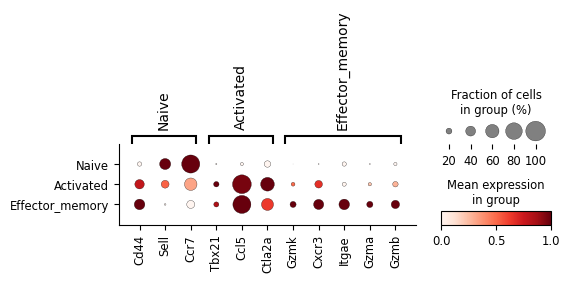

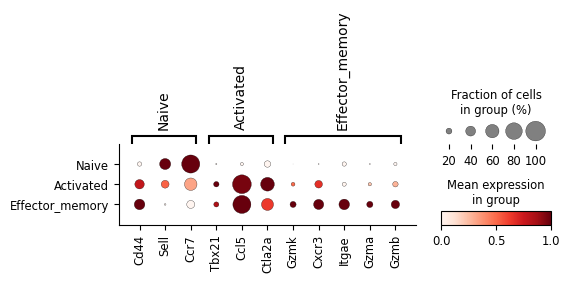

In [33]:

desired_order = ["Naive","Activated","Effector_memory"

]

mdata["gex"].obs["cell_annotation_05"] = (
    mdata["gex"]
    .obs["cell_annotation_05"]
    .astype("category")
    .cat.reorder_categories(desired_order, ordered=True)
)

sc.pl.dotplot(
    mdata["gex"],
    gene_markers,
    groupby="cell_annotation_05",
    standard_scale="var",
    dendrogram=False,
    swap_axes=False,  save = "annotation.svg"
)

sc.pl.dotplot(
    mdata["gex"],
    gene_markers,
    groupby="cell_annotation_05",
    standard_scale="var",
    dendrogram=False,
    swap_axes=False#, save = "annotation.png"
)




plt.close()

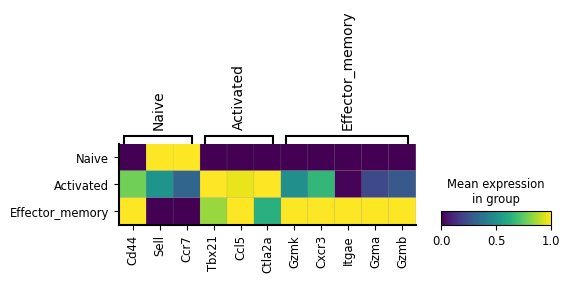

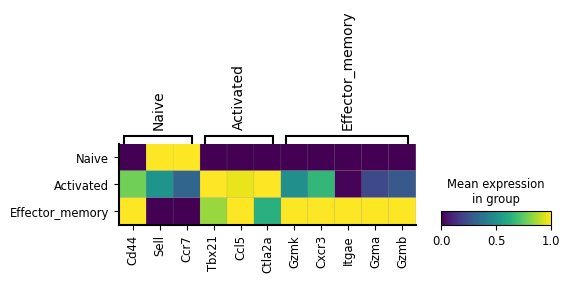

In [34]:
sc.pl.matrixplot(
    mdata["gex"],
    gene_markers,
    groupby="cell_annotation_05",
    standard_scale="var",
    dendrogram=False,
    swap_axes=False#, save = "annotation.svg"
)

sc.pl.matrixplot(
    mdata["gex"],
    gene_markers,
    groupby="cell_annotation_05",
    standard_scale="var",
    dendrogram=False,
    swap_axes=False#, save = "annotation.png"
)



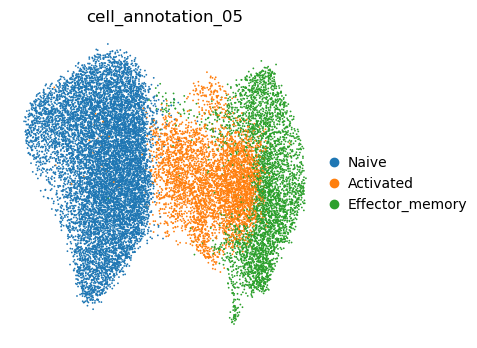

In [35]:
sc.pl.umap(
    mdata["gex"], color="cell_annotation_05", frameon=False  # , legend_loc="on data"
)

In [37]:
mdata.update()

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [40]:
mdata

MuData object with n_obs × n_vars = 18315 × 18038
  3 modalities
    gex:	18263 x 18038
      obs:	'sample_id', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'rna_leiden', 'doublet_score', 'predicted_doublet', 'rna_leiden_12', 'rna_leiden_2', 'cell_annotation_05'
      var:	'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
      uns:	'condition_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'predicted_doublet_colors', 'rna_leiden', 'rna_leiden_colors', 'sample_id_colors', 'scrublet', 'umap', 'rna_leiden_12', 'rna_leiden_2', 'rna_leiden_12_colors', 'cell_annotation_05_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    airr:	15207 x 0
      obsm:	'airr'
    adt:	15207 x 0
      obs:	'sample_id'
      var:	'gene_ids', 'feature_types'

In [41]:
mdata.write_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/single_cell_normal/002_annotate_mudata_normal.h5mu")

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [ ]:
sc.tl.rank_genes_groups(
    mdata["gex"], groupby="cell_annotation_05", method="wilcoxon", key_added="dea_cell_annotation_05"
)

In [ ]:
sc.tl.dendrogram(
    mdata["gex"],
    groupby="cell_annotation_05",
)

sc.pl.rank_genes_groups_dotplot(
    mdata["gex"], groupby="cell_annotation_05", standard_scale="var", n_genes=5, key="dea_cell_annotation_05"
)

In [ ]:
mdata["gex"].obs

In [ ]:
import scanpy as sc

# 1. Pull out your GEX layer if working inside MuData
# (If you are working on a standalone AnnData, just use your adata object directly)
adata_gex = mdata["gex"].copy()

# 2. Identify ribosomal genes (case-insensitive for safety, captures Rps, Rpl, RPS, RPL)
is_ribo = adata_gex.var_names.str.startswith(("Rps", "Rpl", "RPS", "RPL"))

# 3. Subset the object to EXCLUDE ribosomal genes from the expression matrix
# This removes them from the columns of adata.X so they cannot be ranked
adata_filtered = adata_gex[:, ~is_ribo].copy()

print(f"Removed {sum(is_ribo)} ribosomal genes.")
print(f"Remaining genes for ranking: {adata_filtered.shape[1]}")



In [ ]:
sc.tl.rank_genes_groups(
    adata_filtered, groupby="cell_annotation_05", method="wilcoxon", use_raw=False,  key_added="dea_cell_annotation_05"
)

In [ ]:
sc.tl.dendrogram(
    adata_filtered,
    groupby="cell_annotation_05",
)

sc.pl.rank_genes_groups_dotplot(
    adata_filtered, groupby="cell_annotation_05", standard_scale="var", n_genes=5, key="dea_cell_annotation_05"
)

In [ ]:
ranked_genes_df = sc.get.rank_genes_groups_df(
    adata_filtered, group=None, key="dea_cell_annotation_05"
)

In [ ]:
ranked_genes_df

In [ ]:
import pandas as pd
import scanpy as sc

# 1. Fetch the raw ranked genes data frame from your specific analysis key
raw_df = sc.get.rank_genes_groups_df(adata_filtered, group=None, key="dea_cell_annotation_05")

# 2. Group by each cluster ('group') and grab the top 10 genes using .head(10)
# We use a lambda function to reset the index (0-9) so they line up perfectly
top10_df = (
    raw_df.groupby("group")["names"]
    .apply(lambda x: x.head(10).reset_index(drop=True))
    .unstack(level=0)
)

# 3. Clean up the DataFrame index name for a polished table
top10_df.index.name = "Rank"
top10_df.index = top10_df.index + 1  # Shifts index from 0-9 to 1-10


In [ ]:
top10_df

In [ ]:
sc.pl.umap(
    mdata["gex"], color=["rna_leiden_12","cell_annotation_05"], frameon=False  # , legend_loc="on data"
)